## classifier improvements

try feature engineering, k-fold CV, and gradient boosting to see if we can beat the baseline AdaBoost

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
import pickle
import os

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.ensemble import AdaBoostClassifier, HistGradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc

os.makedirs('../plots', exist_ok=True)

In [2]:
features = ['PT1', 'PT2', 'P1', 'P2', 'TotalPT', 'VertexChisq', 'Isolation', 'MASS']

signal     = pd.read_csv('../data/signal_Bs2MuMu.txt',         sep=r'\s+', header=None, names=features)
background = pd.read_csv('../data/background_combinatorial.txt', sep=r'\s+', header=None, names=features)
signal     = signal.apply(pd.to_numeric, errors='coerce').dropna().reset_index(drop=True)
background = background.apply(pd.to_numeric, errors='coerce').dropna().reset_index(drop=True)

features7 = [f for f in features if f != 'MASS']

with open('../bdt_results.json') as fh:
    bdt_results = json.load(fh)

print(f"baseline AdaBoost accuracy (single split): {bdt_results['acc_7feat']:.4f}")
print(f"signal: {len(signal)}, background: {len(background)}")

baseline AdaBoost accuracy (single split): 0.9287
signal: 10000, background: 10000


### feature engineering

add variables that exploit the two-body decay kinematics — asymmetries, ratios, log transforms. none of them use MASS so the mass distribution stays unbiased.

In [3]:
def engineer_features(df):
    out = df.copy()
    out['PT_asym']      = (df['PT1'] - df['PT2']) / (df['PT1'] + df['PT2'] + 1e-12)
    out['P_asym']       = (df['P1']  - df['P2'])  / (df['P1']  + df['P2']  + 1e-12)
    out['PT_ratio']     = df[['PT1', 'PT2']].min(axis=1) / (df[['PT1', 'PT2']].max(axis=1) + 1e-12)
    out['log_VtxChi2']  = np.log(df['VertexChisq'].clip(lower=1e-6))
    out['log1p_TotPT']  = np.log1p(df['TotalPT'].clip(lower=0))
    out['Iso_x_VtxChi2'] = df['Isolation'] * df['VertexChisq']
    return out

signal_eng     = engineer_features(signal[features7])
background_eng = engineer_features(background[features7])

engineered_features = ['PT_asym', 'P_asym', 'PT_ratio', 'log_VtxChi2', 'log1p_TotPT', 'Iso_x_VtxChi2']
all_features = features7 + engineered_features

print(f"raw: {len(features7)}, engineered: {len(engineered_features)}, total: {len(all_features)}")

raw: 7, engineered: 6, total: 13


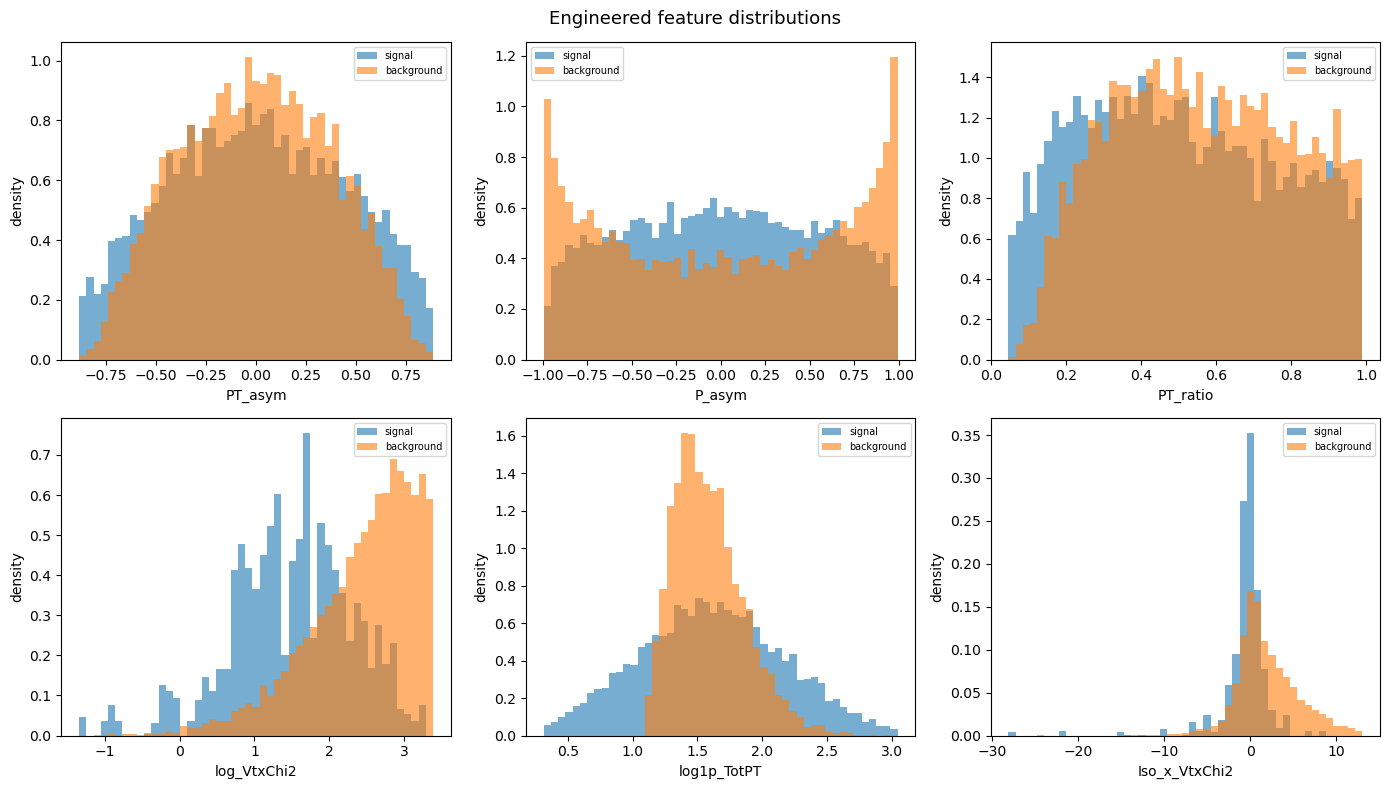

In [4]:
#check how well the engineered features separate signal and background
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, feat in zip(axes.ravel(), engineered_features):
    lo = min(signal_eng[feat].quantile(0.01), background_eng[feat].quantile(0.01))
    hi = max(signal_eng[feat].quantile(0.99), background_eng[feat].quantile(0.99))
    bins = np.linspace(lo, hi, 50)
    ax.hist(signal_eng[feat],     bins=bins, alpha=0.6, density=True, label='signal')
    ax.hist(background_eng[feat], bins=bins, alpha=0.6, density=True, label='background')
    ax.set_xlabel(feat)
    ax.set_ylabel('density')
    ax.legend(fontsize=7)
plt.suptitle('Engineered feature distributions', fontsize=13)
plt.tight_layout()
plt.savefig('../plots/engineered_features.png', dpi=150, bbox_inches='tight')
plt.show()

### k-fold CV comparison

compare AdaBoost vs gradient boosting, with and without engineered features. 10-fold stratified CV.

In [5]:
def make_dataset(sig_df, bkg_df, feat_list):
    X = pd.concat([sig_df[feat_list], bkg_df[feat_list]], axis=0).reset_index(drop=True)
    y = np.concatenate([np.ones(len(sig_df)), np.zeros(len(bkg_df))])
    return X, y

X_raw, y = make_dataset(signal,     background,     features7)
X_eng, _ = make_dataset(signal_eng, background_eng, all_features)

base_tree = DecisionTreeClassifier(max_depth=2, min_samples_leaf=50, random_state=42)

classifiers = {
    'AdaBoost (7 raw)': (
        AdaBoostClassifier(estimator=base_tree, n_estimators=100, learning_rate=0.5, random_state=42),
        X_raw, features7
    ),
    'AdaBoost (13 eng)': (
        AdaBoostClassifier(estimator=base_tree, n_estimators=100, learning_rate=0.5, random_state=42),
        X_eng, all_features
    ),
    'GradBoost (7 raw)': (
        HistGradientBoostingClassifier(
            max_depth=4, max_iter=200, learning_rate=0.1,
            min_samples_leaf=50, random_state=42
        ),
        X_raw, features7
    ),
    'GradBoost (13 eng)': (
        HistGradientBoostingClassifier(
            max_depth=4, max_iter=200, learning_rate=0.1,
            min_samples_leaf=50, random_state=42
        ),
        X_eng, all_features
    ),
}

#10-fold stratified CV
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

cv_results = {}
for name, (clf, X, feats) in classifiers.items():
    scores = cross_validate(clf, X, y, cv=skf, scoring='accuracy',
                            return_train_score=True, n_jobs=-1)
    cv_results[name] = {
        'test_mean':  scores['test_score'].mean(),
        'test_std':   scores['test_score'].std(),
        'train_mean': scores['train_score'].mean(),
        'train_std':  scores['train_score'].std(),
        'folds':      scores['test_score'].tolist(),
    }
    print(f"{name:25s}  test = {cv_results[name]['test_mean']:.4f} +/- {cv_results[name]['test_std']:.4f}"
          f"   train = {cv_results[name]['train_mean']:.4f} +/- {cv_results[name]['train_std']:.4f}")

AdaBoost (7 raw)           test = 0.9292 +/- 0.0060   train = 0.9302 +/- 0.0021


AdaBoost (13 eng)          test = 0.9398 +/- 0.0067   train = 0.9419 +/- 0.0015


GradBoost (7 raw)          test = 0.9707 +/- 0.0038   train = 0.9779 +/- 0.0008


GradBoost (13 eng)         test = 0.9730 +/- 0.0029   train = 0.9818 +/- 0.0005


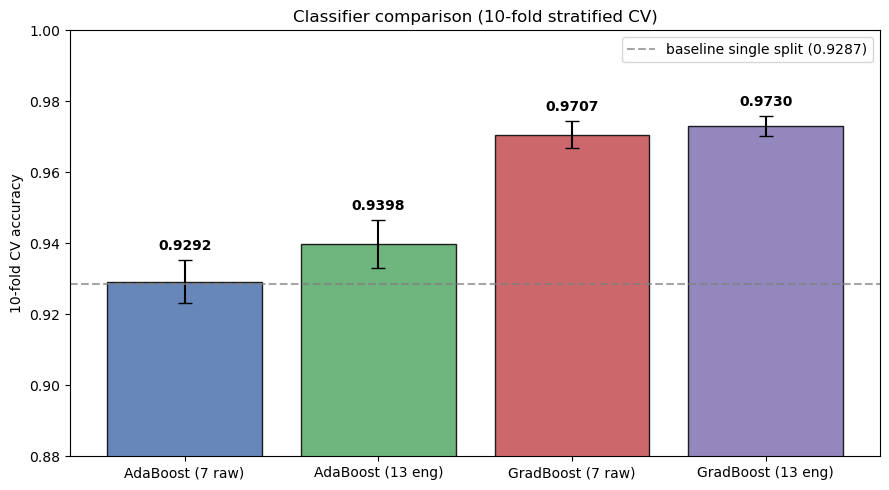

In [6]:
# plot CV accuracy comparison
fig, ax = plt.subplots(figsize=(9, 5))
names  = list(cv_results.keys())
means  = [cv_results[n]['test_mean'] for n in names]
stds   = [cv_results[n]['test_std']  for n in names]
colors = ['#4c72b0', '#55a868', '#c44e52', '#8172b2']

bars = ax.bar(names, means, yerr=stds, capsize=5, color=colors, alpha=0.85, edgecolor='black')
ax.set_ylabel('10-fold CV accuracy')
ax.set_title('Classifier comparison (10-fold stratified CV)')
ax.set_ylim(0.88, 1.0)
for bar, m, s in zip(bars, means, stds):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + s + 0.002,
            f'{m:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# add baseline single-split reference
ax.axhline(bdt_results['acc_7feat'], color='gray', linestyle='--', alpha=0.7,
           label=f"baseline single split ({bdt_results['acc_7feat']:.4f})")
ax.legend()
plt.tight_layout()
plt.savefig('../plots/cv_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### ROC curves and confusion matrices

retrain on 70/30 split for direct comparison with the baseline

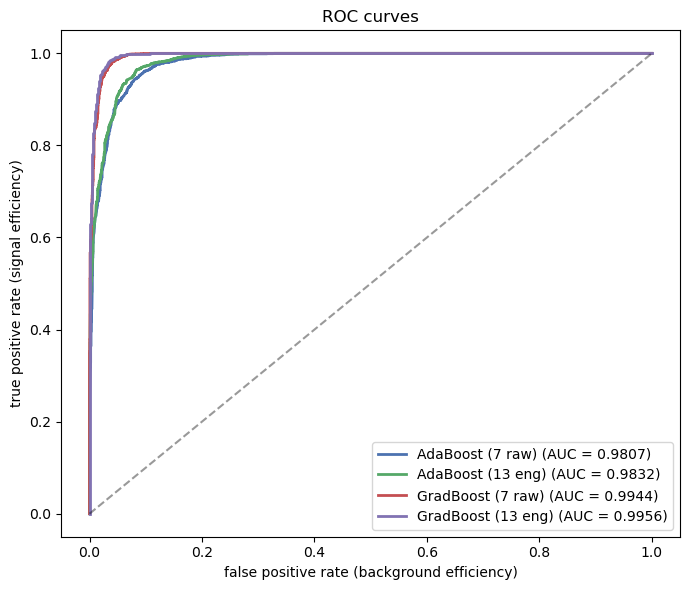

In [7]:
from sklearn.model_selection import train_test_split

# train/test split matching the baseline
X_train_r, X_test_r, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.3, random_state=42, stratify=y)
X_train_e, X_test_e, _, _ = train_test_split(
    X_eng, y, test_size=0.3, random_state=42, stratify=y)

# retrain all four models on this split
model_configs = [
    ('AdaBoost (7 raw)',
     AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=2, min_samples_leaf=50, random_state=42),
                        n_estimators=100, learning_rate=0.5, random_state=42),
     X_train_r, X_test_r),
    ('AdaBoost (13 eng)',
     AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=2, min_samples_leaf=50, random_state=42),
                        n_estimators=100, learning_rate=0.5, random_state=42),
     X_train_e, X_test_e),
    ('GradBoost (7 raw)',
     HistGradientBoostingClassifier(max_depth=4, max_iter=200, learning_rate=0.1,
                                     min_samples_leaf=50, random_state=42),
     X_train_r, X_test_r),
    ('GradBoost (13 eng)',
     HistGradientBoostingClassifier(max_depth=4, max_iter=200, learning_rate=0.1,
                                     min_samples_leaf=50, random_state=42),
     X_train_e, X_test_e),
]

models = {}
for name, clf, X_tr, X_te in model_configs:
    clf.fit(X_tr, y_train)
    models[name] = (clf, X_te)

# ROC curves
fig, ax = plt.subplots(figsize=(7, 6))
colors_roc = ['#4c72b0', '#55a868', '#c44e52', '#8172b2']
for (name, (clf, X_te)), col in zip(models.items(), colors_roc):
    if hasattr(clf, 'predict_proba'):
        y_score = clf.predict_proba(X_te)[:, 1]
    else:
        y_score = clf.decision_function(X_te)
    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=col, lw=2, label=f'{name} (AUC = {roc_auc:.4f})')

ax.plot([0, 1], [0, 1], 'k--', alpha=0.4)
ax.set_xlabel('false positive rate (background efficiency)')
ax.set_ylabel('true positive rate (signal efficiency)')
ax.set_title('ROC curves')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('../plots/roc_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
print(f"{'Model':25s}  {'Accuracy':>8s}  {'Sig eff':>8s}  {'Bkg eff':>8s}  {'Bkg rej':>8s}")
print('-' * 72)

detail_results = {}
for name, (clf, X_te) in models.items():
    y_pred = clf.predict(X_te)
    acc    = accuracy_score(y_test, y_pred)
    cm     = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    sig_eff = tp / (tp + fn)
    bkg_eff = fp / (fp + tn)
    bkg_rej = tn / (tn + fp)
    detail_results[name] = {
        'accuracy': acc, 'sig_eff': sig_eff, 'bkg_eff': bkg_eff, 'bkg_rej': bkg_rej
    }
    print(f"{name:25s}  {acc:8.4f}  {sig_eff:8.4f}  {bkg_eff:8.4f}  {bkg_rej:8.4f}")

Model                      Accuracy   Sig eff   Bkg eff   Bkg rej
------------------------------------------------------------------------
AdaBoost (7 raw)             0.9287    0.9313    0.0740    0.9260
AdaBoost (13 eng)            0.9377    0.9430    0.0677    0.9323
GradBoost (7 raw)            0.9695    0.9853    0.0463    0.9537
GradBoost (13 eng)           0.9727    0.9887    0.0433    0.9567


### feature importances

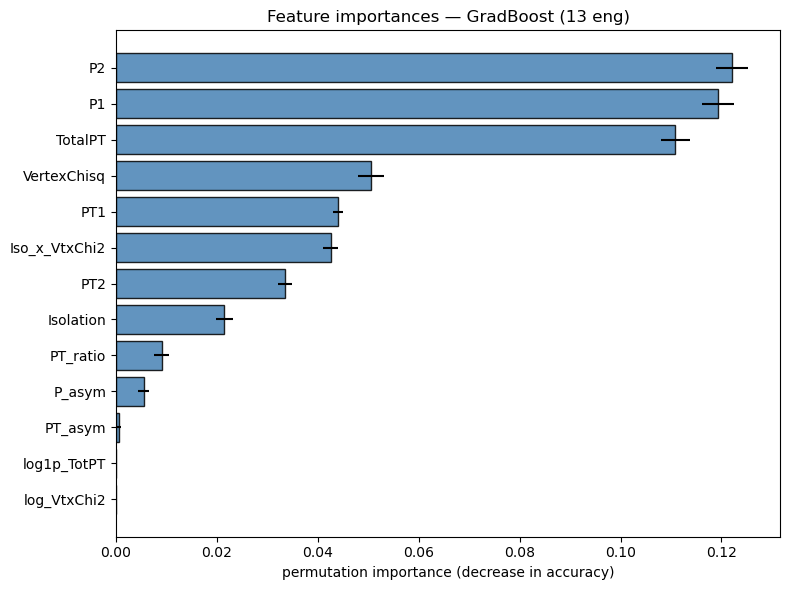

In [9]:
best_clf = models['GradBoost (13 eng)'][0]

from sklearn.inspection import permutation_importance

perm_imp = permutation_importance(best_clf, X_test_e, y_test, n_repeats=10,
                                   random_state=42, n_jobs=-1)
imp_df = pd.DataFrame({
    'Feature':    all_features,
    'Importance':  perm_imp.importances_mean,
    'Std':         perm_imp.importances_std,
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(imp_df['Feature'], imp_df['Importance'], xerr=imp_df['Std'],
        color='steelblue', alpha=0.85, edgecolor='black')
ax.set_xlabel('permutation importance (decrease in accuracy)')
ax.set_title('Feature importances — GradBoost (13 eng)')
plt.tight_layout()
plt.savefig('../plots/feature_importance_gradboost.png', dpi=150, bbox_inches='tight')
plt.show()

### overtraining check

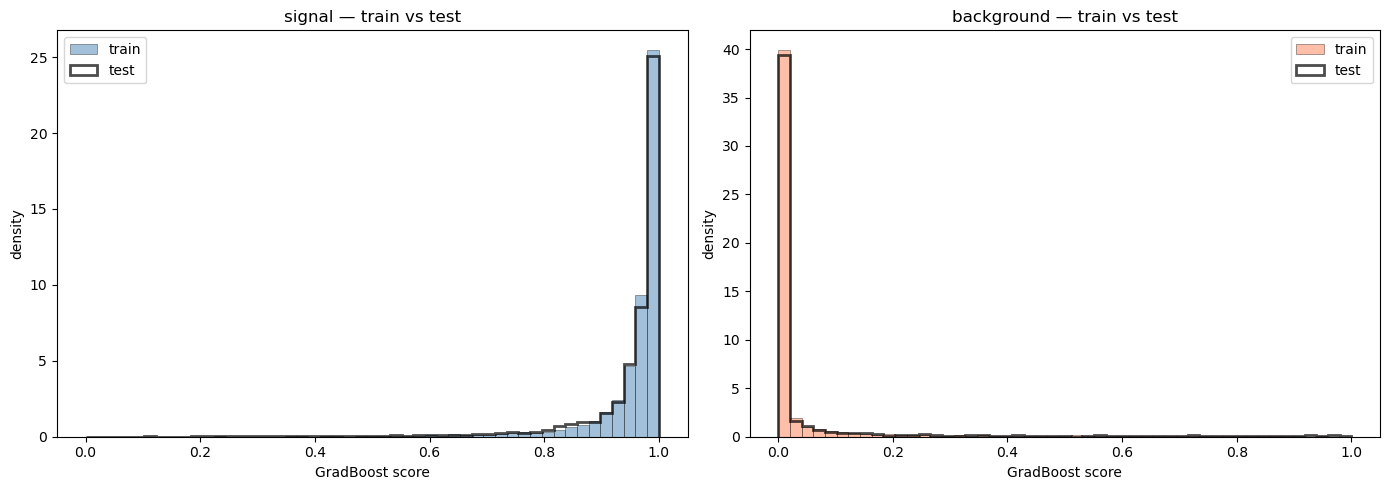

In [10]:
#compare score distributions on train vs test
scores_train = best_clf.predict_proba(X_train_e)[:, 1]
scores_test  = best_clf.predict_proba(X_test_e)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
bins = np.linspace(0, 1, 50)

for ax, label, mask_train, mask_test, color in [
    (axes[0], 'signal',     y_train == 1, y_test == 1, 'steelblue'),
    (axes[1], 'background', y_train == 0, y_test == 0, 'coral'),
]:
    ax.hist(scores_train[mask_train], bins=bins, density=True, alpha=0.5,
            label='train', color=color, edgecolor='black', linewidth=0.5)
    ax.hist(scores_test[mask_test],   bins=bins, density=True, alpha=0.7,
            label='test',  histtype='step', color='black', linewidth=2)
    ax.set_xlabel('GradBoost score')
    ax.set_ylabel('density')
    ax.set_title(f'{label} — train vs test')
    ax.legend()

plt.tight_layout()
plt.savefig('../plots/overtraining_check.png', dpi=150, bbox_inches='tight')
plt.show()

### apply best model to full dataset

In [11]:
sig_pass_new = best_clf.predict(signal_eng[all_features]).astype(bool)
bkg_pass_new = best_clf.predict(background_eng[all_features]).astype(bool)

sig_eff_new = sig_pass_new.mean()
bkg_eff_new = bkg_pass_new.mean()

print("GradBoost + engineered features:")
print(f"  signal efficiency:     {sig_eff_new:.4f}  ({int(sig_pass_new.sum())}/{len(signal)})")
print(f"  background efficiency: {bkg_eff_new:.4f}  ({int(bkg_pass_new.sum())}/{len(background)})")
print()
print("baseline AdaBoost (7 raw):")
print(f"  signal efficiency:     {bdt_results['signal_efficiency']:.4f}")
print(f"  background efficiency: {bdt_results['background_efficiency']:.4f}")

N_SIG, N_BKG = 50, 2000
sens_new  = (N_SIG * sig_eff_new)  / np.sqrt(N_BKG * bkg_eff_new)
sens_base = (N_SIG * bdt_results['signal_efficiency']) / np.sqrt(N_BKG * bdt_results['background_efficiency'])
print(f"\nS/sqrt(B) — improved: {sens_new:.4f},  baseline: {sens_base:.4f}")
print(f"sensitivity gain: {sens_new/sens_base:.3f}x")
print(f"=> runtime reduction: {(sens_base/sens_new)**2:.3f}x")

GradBoost + engineered features:
  signal efficiency:     0.9926  (9926/10000)
  background efficiency: 0.0345  (345/10000)

baseline AdaBoost (7 raw):
  signal efficiency:     0.9305
  background efficiency: 0.0726

S/sqrt(B) — improved: 5.9747,  baseline: 3.8610
sensitivity gain: 1.547x
=> runtime reduction: 0.418x


In [12]:
with open('../improved_model.pkl', 'wb') as fh:
    pickle.dump(best_clf, fh)

improved_results = {
    'cv_results':             cv_results,
    'detail_results':         detail_results,
    'signal_efficiency_improved':     float(sig_eff_new),
    'background_efficiency_improved': float(bkg_eff_new),
    'sensitivity_gain':               float(sens_new / sens_base),
    'engineered_features':            engineered_features,
    'all_features':                   all_features,
}
with open('../improved_results.json', 'w') as fh:
    json.dump(improved_results, fh, indent=2)

print("saved improved_model.pkl and improved_results.json")

saved improved_model.pkl and improved_results.json
